# 04 — Fault Classification Models
**NGAFID · Cessna-172 · 19-class fault identification on anomalous flights**

CS3315 · Naval Postgraduate School · MSCS Q3 2026

**Ivan Barbosa Mejia**

---

## Key differences from AD

| Aspect | AD (NB03) | FC (this NB) |
|---|---|---|
| Sample | 11,446 flights (all) | **5,602 anomalous flights** |
| Classes | 2 (binary) | **19 fault types** |
| Imbalance | 1.04:1 (trivial) | **38:1 (Gini ≈ 0.60)** |
| Main repr. | Repr B (global stats) | **Repr F++ (cross-cylinder)** |
| Metric | F1-macro ≈ F1-binary | **F1-macro (the only valid one)** |
| Difficulty | Moderate | **High** — sparse signal, few samples in rare classes |

**DL benchmarks (paper):** MMK Net F1=0.623 · ConvTokMHSA F1=0.208 · Oracle K=4 ceiling F1=0.420

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────
import json, warnings, time
from pathlib import Path
from itertools import combinations

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import randint, uniform, loguniform

from sklearn.linear_model    import LogisticRegression
from sklearn.svm             import LinearSVC
from sklearn.calibration     import CalibratedClassifierCV
from sklearn.ensemble        import RandomForestClassifier, VotingClassifier
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, learning_curve
from sklearn.metrics         import (
    f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'serif', 'font.size': 11,
    'axes.labelsize': 12, 'axes.titlesize': 12,
    'legend.fontsize': 10, 'axes.grid': True, 'grid.alpha': 0.3,
})
NPS_BLUE, NPS_GOLD = '#003087', '#B8960C'
RNG = 42

SAVE    = Path('datasets')
FIGS    = Path('figures');  FIGS.mkdir(exist_ok=True)
RESULTS = Path('results');  RESULTS.mkdir(exist_ok=True)

SENSORS = [
    'volt1','volt2','amp1','amp2','FQtyL','FQtyR',
    'E1 FFlow','E1 OilT','E1 OilP','E1 RPM',
    'E1 CHT1','E1 CHT2','E1 CHT3','E1 CHT4',
    'E1 EGT1','E1 EGT2','E1 EGT3','E1 EGT4',
    'OAT','IAS','VSpd','NormAc','AltMSL'
]
STATS  = ['mean','std','min','max','range','skew','kurt','slope']
FEAT_B = [f'{s}_{st}' for s in SENSORS for st in STATS]
SENSOR_GROUPS = {
    'Electrical' : ['volt1','volt2','amp1','amp2'],
    'Fuel'       : ['FQtyL','FQtyR','E1 FFlow'],
    'Engine'     : ['E1 OilT','E1 OilP','E1 RPM'],
    'CHT'        : ['E1 CHT1','E1 CHT2','E1 CHT3','E1 CHT4'],
    'EGT'        : ['E1 EGT1','E1 EGT2','E1 EGT3','E1 EGT4'],
    'Flight state': ['OAT','IAS','VSpd','NormAc','AltMSL'],
}
print('Setup OK')

Setup OK


In [2]:
# ── Load FC datasets ─────────────────────────────────────────────────────────
def load_repr(name):
    d = np.load(SAVE / f'{name}.npz')
    return d['X'].astype(np.float32), d['y'].astype(int), d['folds'].astype(int)

reprs = {
    'Repr B'      : load_repr('repr_B_FC'),
    'Repr Bseg3'  : load_repr('repr_Bseg3_FC'),
    'Repr Bseg5'  : load_repr('repr_Bseg5_FC'),
    'Repr Bseg10' : load_repr('repr_Bseg10_FC'),
    'Repr F++'    : load_repr('repr_Fpp_FC'),
}

# Load class weights and fault names
cw_df = pd.read_csv(SAVE / 'fc_class_weights.csv', index_col=0)
CLASS_WEIGHTS = dict(zip(cw_df.index.astype(int), cw_df['weight']))
N_CLASSES = len(CLASS_WEIGHTS)

with open('data/fault_mapping.json') as f:
    fm = json.load(f)
ID2FAULT = {int(k): v for k, v in fm['id_to_fault'].items()}
# Short labels for plots
SHORT = {i: n[:22] for i, n in ID2FAULT.items()}

# Class counts
_, y_all, _ = reprs['Repr B']
CLASS_COUNTS = {c: int((y_all == c).sum()) for c in range(N_CLASSES)}

for name, (X, y, folds) in reprs.items():
    print(f'{name:14s}  X={X.shape}  classes={len(np.unique(y))}  folds={np.unique(folds).tolist()}')

Repr B          X=(5602, 184)  classes=19  folds=[0, 1, 2, 3, 4]
Repr Bseg3      X=(5602, 552)  classes=19  folds=[0, 1, 2, 3, 4]
Repr Bseg5      X=(5602, 920)  classes=19  folds=[0, 1, 2, 3, 4]
Repr Bseg10     X=(5602, 1840)  classes=19  folds=[0, 1, 2, 3, 4]
Repr F++        X=(5602, 224)  classes=19  folds=[0, 1, 2, 3, 4]


---
## 1 · Evaluation Metrics for FC

With 19 classes and a Gini ≈ 0.60, metric selection is critical:

| Metric | Behavior under imbalance | Use |
|---|---|---|
| **F1-macro** | Equal weight to all classes → **strongly penalizes ignoring rare classes** | **Primary** |
| **Accuracy** | Biased toward majority classes — a trivial classifier (`intake gasket` always) reaches ~77% | Context only |
| **Per-class F1** | Shows exactly which classes the model can and cannot learn | Diagnostic |
| **F1-weighted** | Weights by frequency → more lenient with rare classes | Secondary |

> A model that only predicts `intake gasket` would reach accuracy ≈ 77% but F1-macro ≈ 0.04. That is why F1-macro is the only valid metric for guiding FC decisions.

In [3]:
# ── Anti-leakage scaler (NaN-safe, same fix as NB03) ────────────────────────
def scale_fold(X, folds_arr, fold_id):
    tr_mask = folds_arr != fold_id
    te_mask = folds_arr == fold_id
    sc = StandardScaler()
    X_tr = np.nan_to_num(sc.fit_transform(X[tr_mask]),
                         nan=0.0, posinf=0.0, neginf=0.0)
    X_te = np.nan_to_num(sc.transform(X[te_mask]),
                         nan=0.0, posinf=0.0, neginf=0.0)
    return X_tr, X_te, sc, tr_mask, te_mask


# ── CV function for FC (19-class) ───────────────────────────────────────────
def run_cv_fc(model, X, y, folds_arr, n_folds=5, collect_raw=False):
    """
    5-fold CV for the FC task.
    Returns (means, stds, raw_per_fold).
    raw_per_fold contains y_te, y_pred for per-class analysis.
    """
    keys = ['f1_macro', 'f1_weighted', 'acc']
    fold_vals = {k: [] for k in keys}
    raw = [] if collect_raw else None

    for fold_id in range(n_folds):
        X_tr, X_te, _, tr_m, te_m = scale_fold(X, folds_arr, fold_id)
        y_tr, y_te = y[tr_m], y[te_m]

        sw = compute_sample_weight('balanced', y_tr)
        if isinstance(model, XGBClassifier):
            model.fit(X_tr, y_tr, sample_weight=sw)
        else:
            model.fit(X_tr, y_tr)

        y_pred = model.predict(X_te)

        fold_vals['f1_macro'].append(
            f1_score(y_te, y_pred, average='macro', zero_division=0))
        fold_vals['f1_weighted'].append(
            f1_score(y_te, y_pred, average='weighted', zero_division=0))
        fold_vals['acc'].append(accuracy_score(y_te, y_pred))

        if collect_raw:
            raw.append({'y_te': y_te, 'y_pred': y_pred})

    means = {k: float(np.mean(v)) for k, v in fold_vals.items()}
    stds  = {k: float(np.std(v))  for k, v in fold_vals.items()}
    return means, stds, raw


# Sanity check
Xc, yc, fc = reprs['Repr B']
Xtr0, Xte0, _, _, _ = scale_fold(Xc, fc, 0)
assert not np.isnan(Xtr0).any()
print(f'scale_fold OK — train {Xtr0.shape}  test {Xte0.shape}')
print(f'Class distribution: {dict(sorted(CLASS_COUNTS.items())[:5])} ...')

scale_fold OK — train (4479, 184)  test (1123, 184)
Class distribution: {0: 304, 1: 254, 2: 55, 3: 211, 4: 197} ...


---
## 2 · Model Definitions for FC

The same 6 classifiers, adapted for 19 classes with balanced weights.
Imbalance handling is even more critical than in AD: 40 samples of the `baffle rivet` class
in the training fold must compete against 3,448 of `intake gasket`.

In [ ]:
# ── Model factory for FC — optimised for speed ──────────────────────────────
# Changes vs initial version:
#   LR  : saga→lbfgs (10x faster on dense data), max_iter 2000→500
#   SVM : crammer_singer removed (O(n²) classes) → default OvR (O(n))
#   XGB : n_estimators 300→200
#   RF  : max_depth=20 added (avoids unbounded depth on 19-class)
#   Ensemble: LR removed (was the bottleneck); XGB+RF only
def make_models_fc():
    lr = LogisticRegression(
        C=1.0, max_iter=500, solver='lbfgs',
        multi_class='multinomial',
        class_weight='balanced', random_state=RNG)

    svm = CalibratedClassifierCV(
        LinearSVC(C=1.0, max_iter=2000, class_weight='balanced',
                  random_state=RNG),          
        cv=3, n_jobs=-1)

    xgb = XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        objective='multi:softmax', num_class=N_CLASSES,
        eval_metric='mlogloss',
        random_state=RNG, verbosity=0, n_jobs=-1)

    rf = RandomForestClassifier(
        n_estimators=200, max_depth=20,
        class_weight='balanced_subsample',
        random_state=RNG, n_jobs=-1)

    ens = VotingClassifier(          
        estimators=[
            ('xgb', XGBClassifier(n_estimators=200, max_depth=5,
                     learning_rate=0.1, objective='multi:softmax',
                     num_class=N_CLASSES, eval_metric='mlogloss',
                     verbosity=0, random_state=RNG, n_jobs=-1)),
            ('rf',  RandomForestClassifier(n_estimators=200, max_depth=20,
                     class_weight='balanced_subsample',
                     random_state=RNG, n_jobs=-1)),
        ],
        voting='soft', n_jobs=-1)

    knn = KNeighborsClassifier(
        n_neighbors=11, metric='euclidean',
        weights='distance', n_jobs=-1)

    return {
        'LR'           : lr,
        'Linear SVM'   : svm,
        'XGBoost'      : xgb,
        'Random Forest': rf,
        'Ensemble'     : ens,
        'kNN'          : knn,
    }

# Expected time per combination with these settings:
# LR:4-60s  SVM:30-180s  XGB:10-60s  RF:5-30s  Ens:15-90s  kNN:<5s
print('FC models (optimised):', list(make_models_fc().keys()))

FC models (optimised): ['LR', 'Linear SVM', 'XGBoost', 'Random Forest', 'Ensemble', 'kNN']


---
## 3 · Phase 1 — Quick Exploration (6 models × 5 representations = 30 combinations)

**EDA-based hypotheses:**
- Repr F++ > Repr B: inter-cylinder differences should improve FC
- Repr B_seg > Repr B: temporal segmentation helps capture the phase in which the fault appears
- XGB and RF > LR: the fault signal is nonlinear and sparse across a few features

In [5]:
# ── Phase 1: run all 30 combinations ────────────────────────────────────────
model_names = list(make_models_fc().keys())
repr_names  = list(reprs.keys())

results_p1 = {r: {} for r in repr_names}
total = len(model_names) * len(repr_names)
done  = 0
t_start = time.time()

for r_name, (X, y, folds) in reprs.items():
    for m_name, model in make_models_fc().items():
        t0 = time.time()
        means, stds, _ = run_cv_fc(model, X, y, folds)
        elapsed = time.time() - t0
        results_p1[r_name][m_name] = {'means': means, 'stds': stds}
        done += 1
        print(f'[{done:2d}/{total}] {r_name:14s} × {m_name:13s} '
              f'F1={means["f1_macro"]:.3f}±{stds["f1_macro"]:.3f}  '
              f'F1w={means["f1_weighted"]:.3f}  '
              f'Acc={means["acc"]:.3f}  ({elapsed:.0f}s)')

print(f'\nTotal Phase 1 time: {(time.time()-t_start)/60:.1f} min')

[ 1/30] Repr B         × LR            F1=0.086±0.010  F1w=0.087  Acc=0.087  (2s)
[ 2/30] Repr B         × Linear SVM    F1=0.029±0.000  F1w=0.205  Acc=0.373  (57s)
[ 3/30] Repr B         × XGBoost       F1=0.116±0.007  F1w=0.304  Acc=0.372  (48s)
[ 4/30] Repr B         × Random Forest F1=0.047±0.007  F1w=0.238  Acc=0.378  (4s)
[ 5/30] Repr B         × Ensemble      F1=0.059±0.004  F1w=0.271  Acc=0.392  (102s)
[ 6/30] Repr B         × kNN           F1=0.065±0.010  F1w=0.252  Acc=0.342  (0s)
[ 7/30] Repr Bseg3     × LR            F1=0.086±0.015  F1w=0.128  Acc=0.113  (5s)
[ 8/30] Repr Bseg3     × Linear SVM    F1=0.031±0.003  F1w=0.207  Acc=0.375  (492s)
[ 9/30] Repr Bseg3     × XGBoost       F1=0.087±0.009  F1w=0.275  Acc=0.357  (78s)
[10/30] Repr Bseg3     × Random Forest F1=0.045±0.010  F1w=0.234  Acc=0.374  (7s)
[11/30] Repr Bseg3     × Ensemble      F1=0.048±0.004  F1w=0.260  Acc=0.387  (276s)
[12/30] Repr Bseg3     × kNN           F1=0.056±0.007  F1w=0.245  Acc=0.339  (0s)
[13/30]

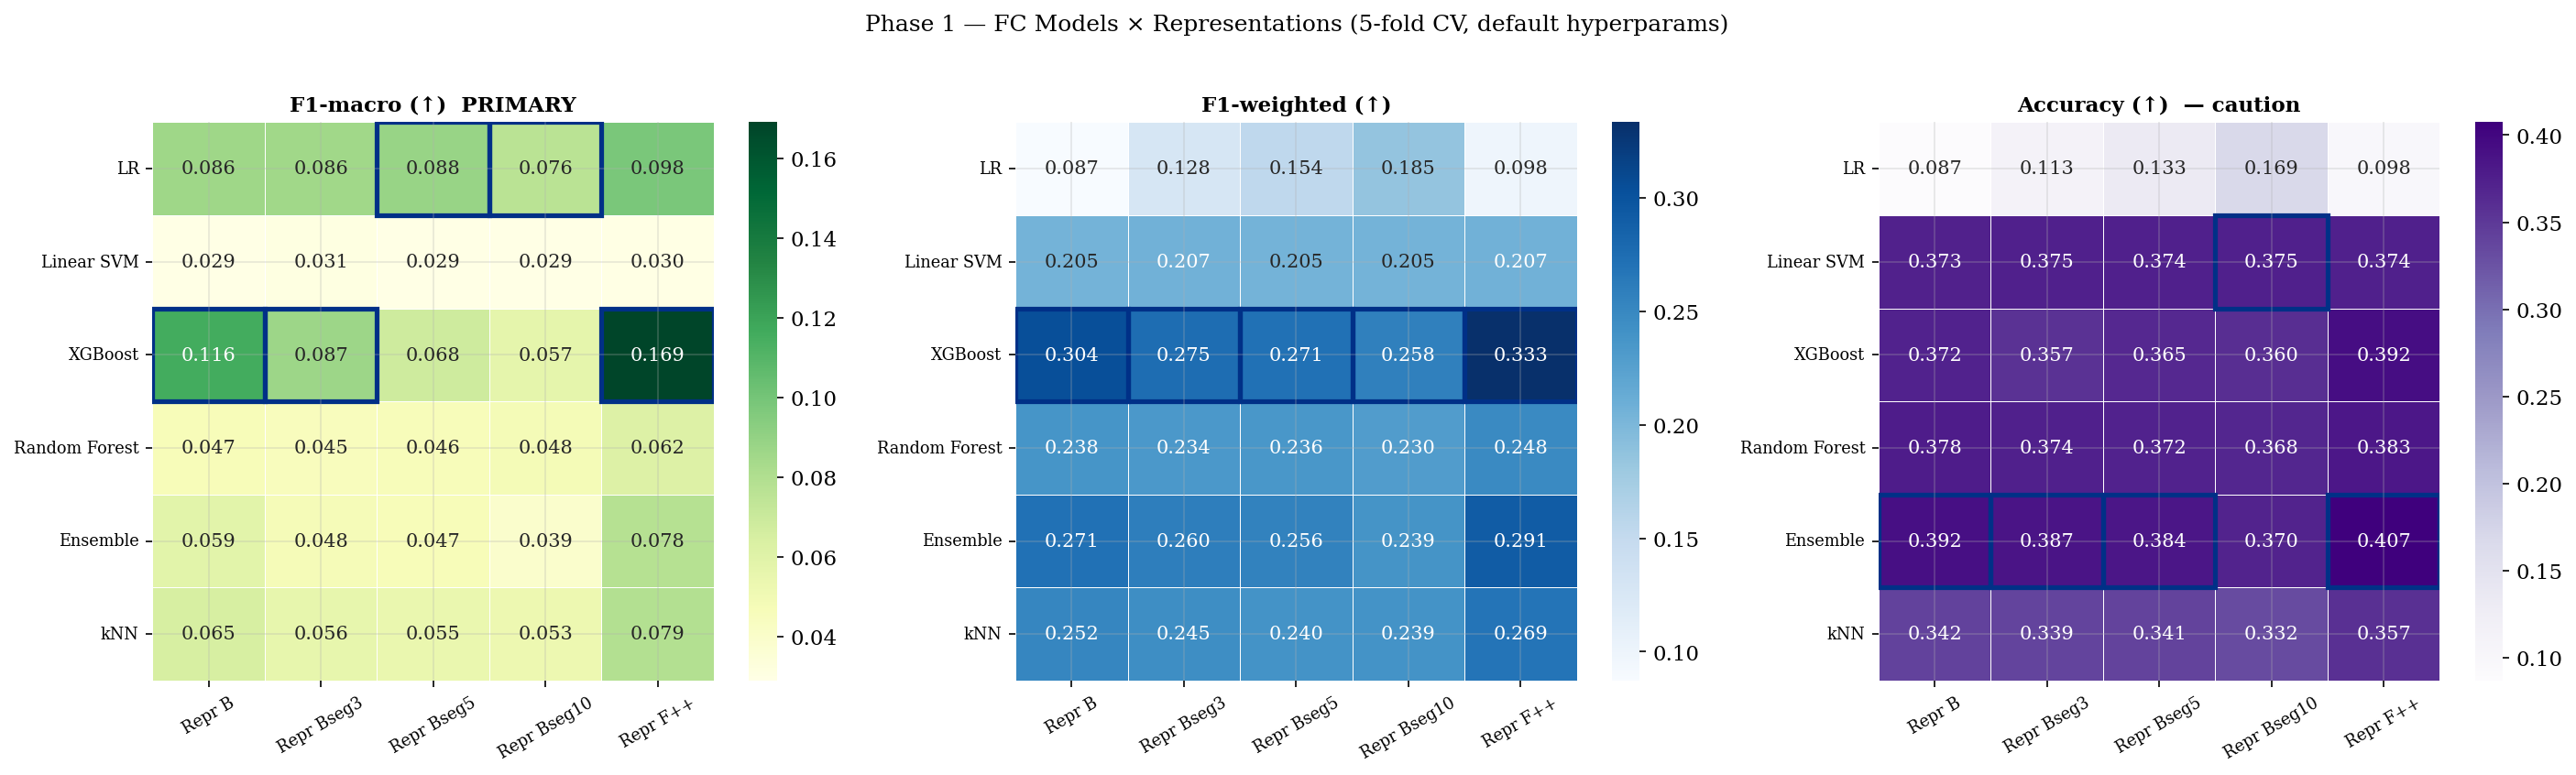


Repr            Model           F1-macro  ±std    Accuracy
----------------------------------------------------------------
Repr F++        XGBoost         0.169     0.026   0.392
Repr B          XGBoost         0.116     0.007   0.372
Repr F++        LR              0.098     0.007   0.098
Repr Bseg5      LR              0.088     0.010   0.133
Repr Bseg3      XGBoost         0.087     0.009   0.357
Repr B          LR              0.086     0.010   0.087
Repr Bseg3      LR              0.086     0.015   0.113
Repr F++        kNN             0.079     0.017   0.357


In [6]:
# ── Phase 1: heatmaps ────────────────────────────────────────────────────────
def to_df(metric):
    df = pd.DataFrame(index=model_names, columns=repr_names, dtype=float)
    for r in repr_names:
        for m in model_names:
            df.loc[m, r] = results_p1[r][m]['means'][metric]
    return df

df_f1m = to_df('f1_macro')
df_f1w = to_df('f1_weighted')
df_acc = to_df('acc')

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

for ax, df, title, cmap in [
    (axes[0], df_f1m, 'F1-macro (↑)  PRIMARY',  'YlGn'),
    (axes[1], df_f1w, 'F1-weighted (↑)',          'Blues'),
    (axes[2], df_acc, 'Accuracy (↑)  — caution', 'Purples'),
]:
    g = sns.heatmap(df.astype(float), ax=ax, annot=True, fmt='.3f',
                    cmap=cmap, linewidths=0.4, linecolor='white',
                    annot_kws={'size': 10})
    best_row = df.idxmax(axis=0)
    for col_i, (col_name, row_name) in enumerate(best_row.items()):
        row_i = list(df.index).index(row_name)
        ax.add_patch(plt.Rectangle((col_i, row_i), 1, 1,
                     fill=False, edgecolor='#003087', lw=2.5))
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=30, labelsize=8.5)
    ax.tick_params(axis='y', rotation=0,  labelsize=8.5)

plt.suptitle('Phase 1 — FC Models × Representations (5-fold CV, default hyperparams)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIGS / 'fc-phase1-heatmap.png', bbox_inches='tight', dpi=300)
plt.show()

# Sorted ranking
pairs = [(r, m, results_p1[r][m]['means']['f1_macro'],
              results_p1[r][m]['stds']['f1_macro'],
              results_p1[r][m]['means']['acc'])
         for r in repr_names for m in model_names]
pairs.sort(key=lambda x: -x[2])
print(f'\n{"Repr":14s}  {"Model":14s}  F1-macro  ±std    Accuracy')
print('-' * 64)
for r, m, f1, std, acc in pairs[:8]:
    print(f'{r:14s}  {m:14s}  {f1:.3f}     {std:.3f}   {acc:.3f}')

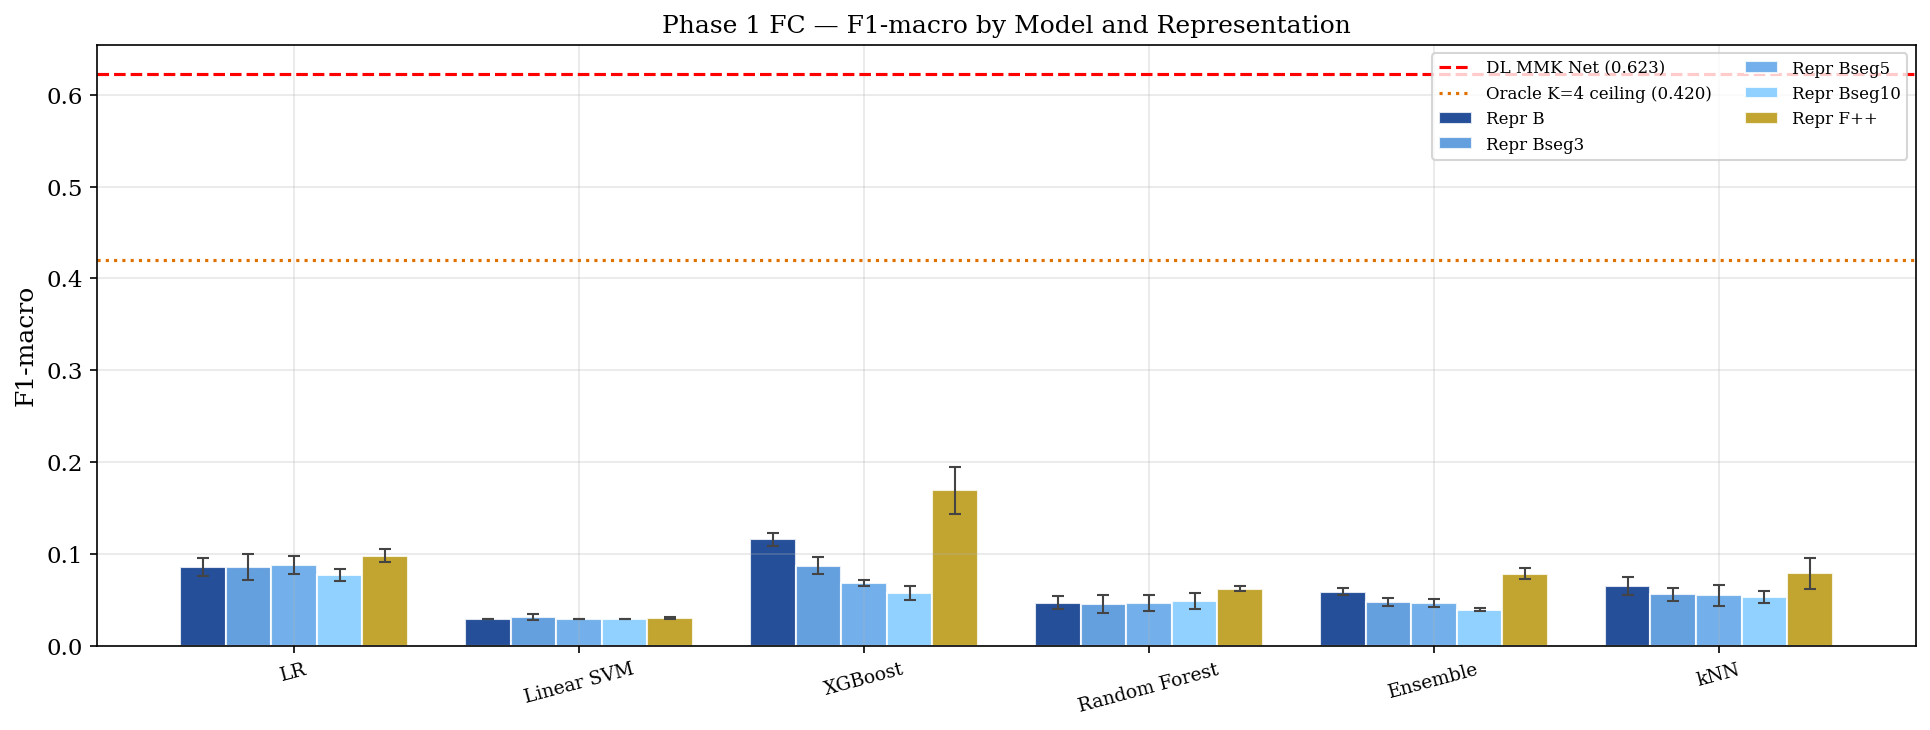

In [7]:
# ── Phase 1: F1-macro improvement vs Repr B baseline ─────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(model_names))
w = 0.16
repr_colors = [NPS_BLUE, '#4a90d9', '#5ba3e8', '#7dc9ff', NPS_GOLD]

for i, (r_name, clr) in enumerate(zip(repr_names, repr_colors)):
    vals = [results_p1[r_name][m]['means']['f1_macro'] for m in model_names]
    errs = [results_p1[r_name][m]['stds']['f1_macro']  for m in model_names]
    offset = (i - 2) * w
    bars = ax.bar(x + offset, vals, w, color=clr, alpha=0.85,
                  edgecolor='white', label=r_name)
    ax.errorbar(x + offset, vals, errs, fmt='none', c='#444',
                capsize=3, lw=1)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, fontsize=9)
ax.set_ylabel('F1-macro')
ax.set_title('Phase 1 FC — F1-macro by Model and Representation')
ax.axhline(0.623, ls='--', c='red',     lw=1.5, label='DL MMK Net (0.623)')
ax.axhline(0.420, ls=':',  c='#e07000', lw=1.5, label='Oracle K=4 ceiling (0.420)')
ax.legend(fontsize=8, loc='upper right', ncol=2)
plt.tight_layout()
plt.savefig(FIGS / 'fc-phase1-bars.png', bbox_inches='tight', dpi=300)
plt.show()

---
## 4 · Phase 2 — Hyperparameter Tuning (RandomizedSearchCV)

Top-3 combinations from the heatmap → `RandomizedSearchCV(n_iter=30, cv=3, scoring='f1_macro')`.

In [8]:
# ── Identify top-3 + define search spaces ───────────────────────────────────
top3 = pairs[:3]
print('Top-3 combinations for tuning:')
for i, (r, m, f1, std, acc) in enumerate(top3):
    print(f'  {i+1}. {r} × {m}   F1={f1:.3f} ± {std:.3f}')

PARAM_SPACES = {
    'LR': {
        'C'      : loguniform(1e-3, 1e2),
        'solver' : ['lbfgs'],
        'penalty': ['l2'],
        'max_iter': [300, 500, 1000],
    },
    'Linear SVM': {
        'base_estimator__C'       : loguniform(1e-2, 1e2),
        'base_estimator__max_iter': [1000, 2000],
    },
    'XGBoost': {
        'n_estimators'    : randint(200, 600),
        'max_depth'       : randint(3, 8),
        'learning_rate'   : loguniform(0.01, 0.3),
        'subsample'       : uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
        'min_child_weight': randint(1, 8),
        'gamma'           : uniform(0, 0.5),
        'reg_alpha'       : loguniform(1e-4, 1.0),
    },
    'Random Forest': {
        'n_estimators'    : randint(200, 600),
        'max_depth'       : [10, 20, 30, None],
        'min_samples_leaf': randint(1, 5),
        'max_features'    : ['sqrt', 'log2', 0.3],
    },
    'Ensemble': {
        'xgb__n_estimators' : randint(200, 500),
        'xgb__max_depth'    : randint(3, 7),
        'xgb__learning_rate': loguniform(0.01, 0.3),
        'rf__n_estimators'  : randint(200, 500),
        'rf__max_depth'     : [10, 20, None],
    },
    'kNN': {
        'n_neighbors': randint(5, 51),
        'metric'     : ['euclidean', 'manhattan'],
        'weights'    : ['uniform', 'distance'],
    },
}

Top-3 combinations for tuning:
  1. Repr F++ × XGBoost   F1=0.169 ± 0.026
  2. Repr B × XGBoost   F1=0.116 ± 0.007
  3. Repr F++ × LR   F1=0.098 ± 0.007


In [9]:
# ── Run RandomizedSearch ─────────────────────────────────────────────────────
tuned_results = {}

for r_name, m_name, _, _, _ in top3:
    X, y, folds = reprs[r_name]
    param_space = PARAM_SPACES.get(m_name)
    if param_space is None:
        continue

    base_model = make_models_fc()[m_name]
    sc_full = StandardScaler()
    X_sc = np.nan_to_num(sc_full.fit_transform(X),
                         nan=0.0, posinf=0.0, neginf=0.0)
    sw = compute_sample_weight('balanced', y)

    search = RandomizedSearchCV(
        base_model, param_space,
        n_iter=30, cv=3, scoring='f1_macro',
        random_state=RNG, n_jobs=-1, verbose=0, refit=True
    )

    print(f'Tuning {r_name} × {m_name}...')
    t0 = time.time()
    if isinstance(base_model, XGBClassifier):
        search.fit(X_sc, y, sample_weight=sw)
    else:
        search.fit(X_sc, y)
    elapsed = time.time() - t0

    print(f'  Best inner CV F1: {search.best_score_:.3f}  ({elapsed:.0f}s)')
    print(f'  Params: {search.best_params_}\n')

    means, stds, _ = run_cv_fc(search.best_estimator_, X, y, folds)
    key = f'{r_name} × {m_name}'
    tuned_results[key] = {
        'means': means, 'stds': stds,
        'repr': r_name, 'model': m_name,
        'best_estimator': search.best_estimator_,
        'params': search.best_params_,
    }
    print(f'  Tuned 5-fold → F1-macro={means["f1_macro"]:.3f}±{stds["f1_macro"]:.3f}  '
          f'F1w={means["f1_weighted"]:.3f}  Acc={means["acc"]:.3f}\n')

Tuning Repr F++ × XGBoost...
  Best inner CV F1: 0.215  (274s)
  Params: {'colsample_bytree': np.float64(0.8099098641033556), 'gamma': np.float64(0.19993048585762774), 'learning_rate': np.float64(0.011720087201588045), 'max_depth': 6, 'min_child_weight': 7, 'n_estimators': 389, 'reg_alpha': np.float64(0.00023036990230378664), 'subsample': np.float64(0.8473544037332349)}

  Tuned 5-fold → F1-macro=0.207±0.024  F1w=0.267  Acc=0.255

Tuning Repr B × XGBoost...
  Best inner CV F1: 0.169  (238s)
  Params: {'colsample_bytree': np.float64(0.8099098641033556), 'gamma': np.float64(0.19993048585762774), 'learning_rate': np.float64(0.011720087201588045), 'max_depth': 6, 'min_child_weight': 7, 'n_estimators': 389, 'reg_alpha': np.float64(0.00023036990230378664), 'subsample': np.float64(0.8473544037332349)}

  Tuned 5-fold → F1-macro=0.176±0.016  F1w=0.237  Acc=0.224

Tuning Repr F++ × LR...
  Best inner CV F1: 0.091  (5s)
  Params: {'C': np.float64(2.0540519425388455), 'max_iter': 500, 'penalty': 

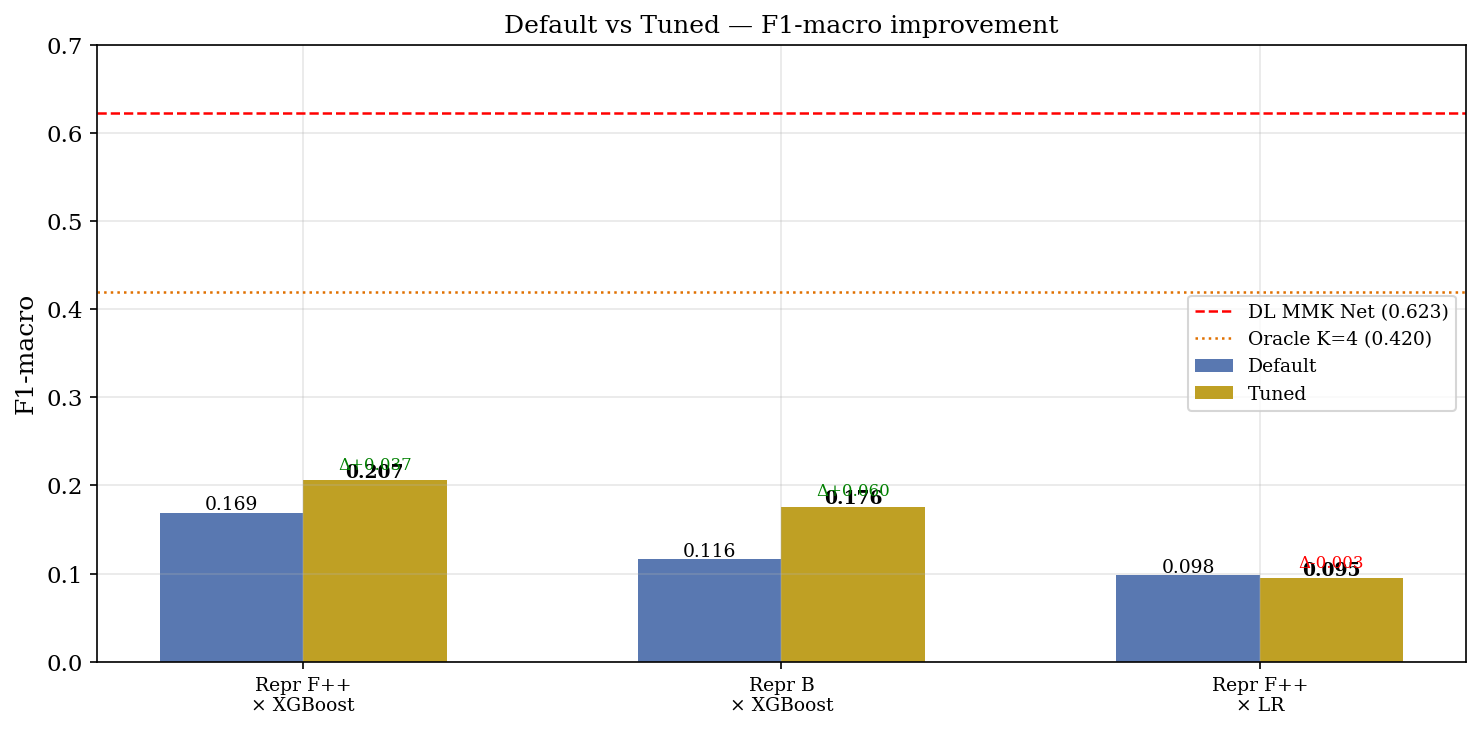

In [10]:
# ── Default vs Tuned comparison ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
labels, f1_def, f1_tun = [], [], []

for key, data in tuned_results.items():
    r, m = data['repr'], data['model']
    labels.append(key.replace(' × ', '\n× '))
    f1_def.append(results_p1[r][m]['means']['f1_macro'])
    f1_tun.append(data['means']['f1_macro'])

x = np.arange(len(labels))
w = 0.3
bars_d = ax.bar(x - w/2, f1_def, w, color=NPS_BLUE, alpha=0.65, label='Default')
bars_t = ax.bar(x + w/2, f1_tun, w, color=NPS_GOLD, alpha=0.9,  label='Tuned')
for i, (vd, vt) in enumerate(zip(f1_def, f1_tun)):
    ax.text(i-w/2, vd+.003, f'{vd:.3f}', ha='center', fontsize=9)
    ax.text(i+w/2, vt+.003, f'{vt:.3f}', ha='center', fontsize=9, fontweight='bold')
    delta = vt - vd
    ax.annotate(f'Δ{delta:+.3f}', xy=(i+w/2, vt+0.012), ha='center',
                fontsize=8, color='green' if delta > 0 else 'red')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('F1-macro')
ax.set_title('Default vs Tuned — F1-macro improvement')
ax.axhline(0.623, ls='--', c='red',     lw=1.2, label='DL MMK Net (0.623)')
ax.axhline(0.420, ls=':',  c='#e07000', lw=1.2, label='Oracle K=4 (0.420)')
ax.legend(fontsize=9)
ax.set_ylim(0, 0.70)
plt.tight_layout()
plt.savefig(FIGS / 'fc-phase2-tuning.png', bbox_inches='tight', dpi=300)
plt.show()

---
## 5 · Phase 3 — Per-Class Analysis

F1-macro hides the detail: classes with F1=0 contribute to the average just as much as classes with F1=0.5.
This section answers: **which classes can the model learn and which can it not?**

Best model: Repr F++ × XGBoost  F1-macro=0.207


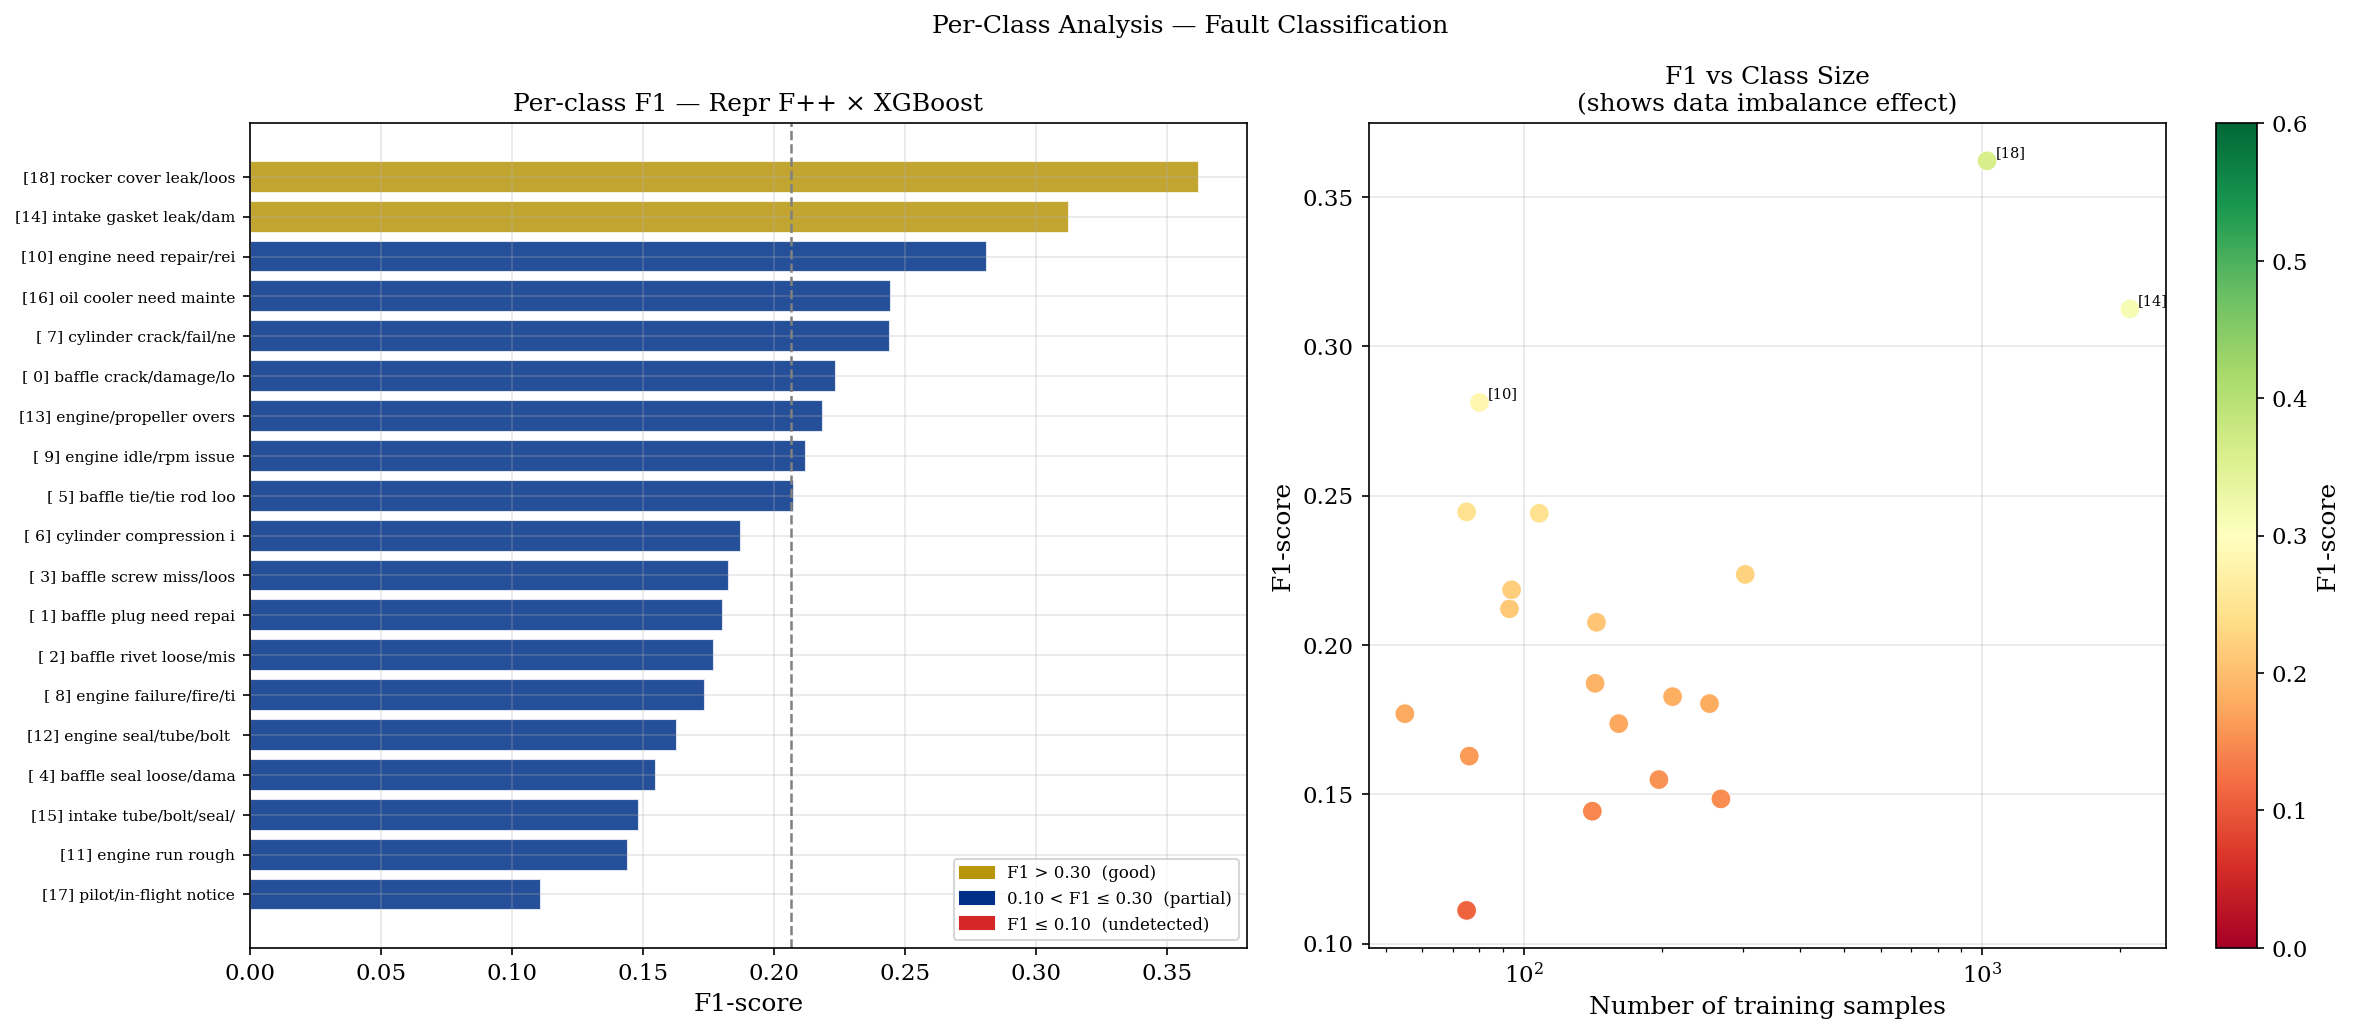

Classes with F1 > 0.30 : 2
Classes with F1 > 0.10 : 19
Classes with F1 = 0.00 : 0
Corr(log n, F1)        : 0.543


In [11]:
# ── Collect raw predictions from best model ───────────────────────────────────
best_key  = max(tuned_results, key=lambda k: tuned_results[k]['means']['f1_macro'])
best_data = tuned_results[best_key]
print(f'Best model: {best_key}  F1-macro={best_data["means"]["f1_macro"]:.3f}')

X_w, y_w, folds_w = reprs[best_data['repr']]
_, _, fold_raw = run_cv_fc(best_data['best_estimator'], X_w, y_w, folds_w,
                            collect_raw=True)

all_yte   = np.concatenate([fd['y_te']   for fd in fold_raw])
all_ypred = np.concatenate([fd['y_pred'] for fd in fold_raw])

# Per-class F1
f1_per = f1_score(all_yte, all_ypred, labels=list(range(N_CLASSES)),
                  average=None, zero_division=0)
n_per  = np.array([CLASS_COUNTS[c] for c in range(N_CLASSES)])

# Sort by F1 descending
order = np.argsort(f1_per)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: per-class F1 bar chart
ax = axes[0]
colors_bar = [NPS_GOLD if f > 0.3 else
              NPS_BLUE  if f > 0.1 else '#d62728'
              for f in f1_per[order]]
bars = ax.barh(range(N_CLASSES), f1_per[order][::-1],
               color=list(reversed(colors_bar)), alpha=0.85, edgecolor='white')
ax.set_yticks(range(N_CLASSES))
ax.set_yticklabels([f'[{order[::-1][i]:2d}] {SHORT[order[::-1][i]]}'
                    for i in range(N_CLASSES)], fontsize=7.5)
ax.set_xlabel('F1-score')
ax.set_title(f'Per-class F1 — {best_key}')
ax.axvline(best_data['means']['f1_macro'], ls='--', c='gray', lw=1.2,
           label=f'F1-macro = {best_data["means"]["f1_macro"]:.3f}')
patches = [
    mpatches.Patch(color=NPS_GOLD,  label='F1 > 0.30  (good)'),
    mpatches.Patch(color=NPS_BLUE,  label='0.10 < F1 ≤ 0.30  (partial)'),
    mpatches.Patch(color='#d62728', label='F1 ≤ 0.10  (undetected)'),
]
ax.legend(handles=patches, fontsize=8, loc='lower right')

# Right: F1 vs class size scatter
ax2 = axes[1]
sc = ax2.scatter(n_per, f1_per, c=f1_per, cmap='RdYlGn',
                  s=90, vmin=0, vmax=0.6, edgecolors='white', lw=0.5, zorder=3)
plt.colorbar(sc, ax=ax2, label='F1-score')
for c in range(N_CLASSES):
    if f1_per[c] > 0.25 or n_per[c] > 800 or f1_per[c] < 0.02:
        ax2.annotate(f'[{c}]', (n_per[c], f1_per[c]),
                     fontsize=7, xytext=(4, 2), textcoords='offset points')
ax2.set_xlabel('Number of training samples')
ax2.set_ylabel('F1-score')
ax2.set_title('F1 vs Class Size\n(shows data imbalance effect)')
ax2.set_xscale('log')

plt.suptitle('Per-Class Analysis — Fault Classification', fontsize=12)
plt.tight_layout()
plt.savefig(FIGS / 'fc-per-class-f1.png', bbox_inches='tight', dpi=300)
plt.show()

print(f'Classes with F1 > 0.30 : {(f1_per > 0.30).sum()}')
print(f'Classes with F1 > 0.10 : {(f1_per > 0.10).sum()}')
print(f'Classes with F1 = 0.00 : {(f1_per == 0.00).sum()}')
print(f'Corr(log n, F1)        : {np.corrcoef(np.log(n_per), f1_per)[0,1]:.3f}')

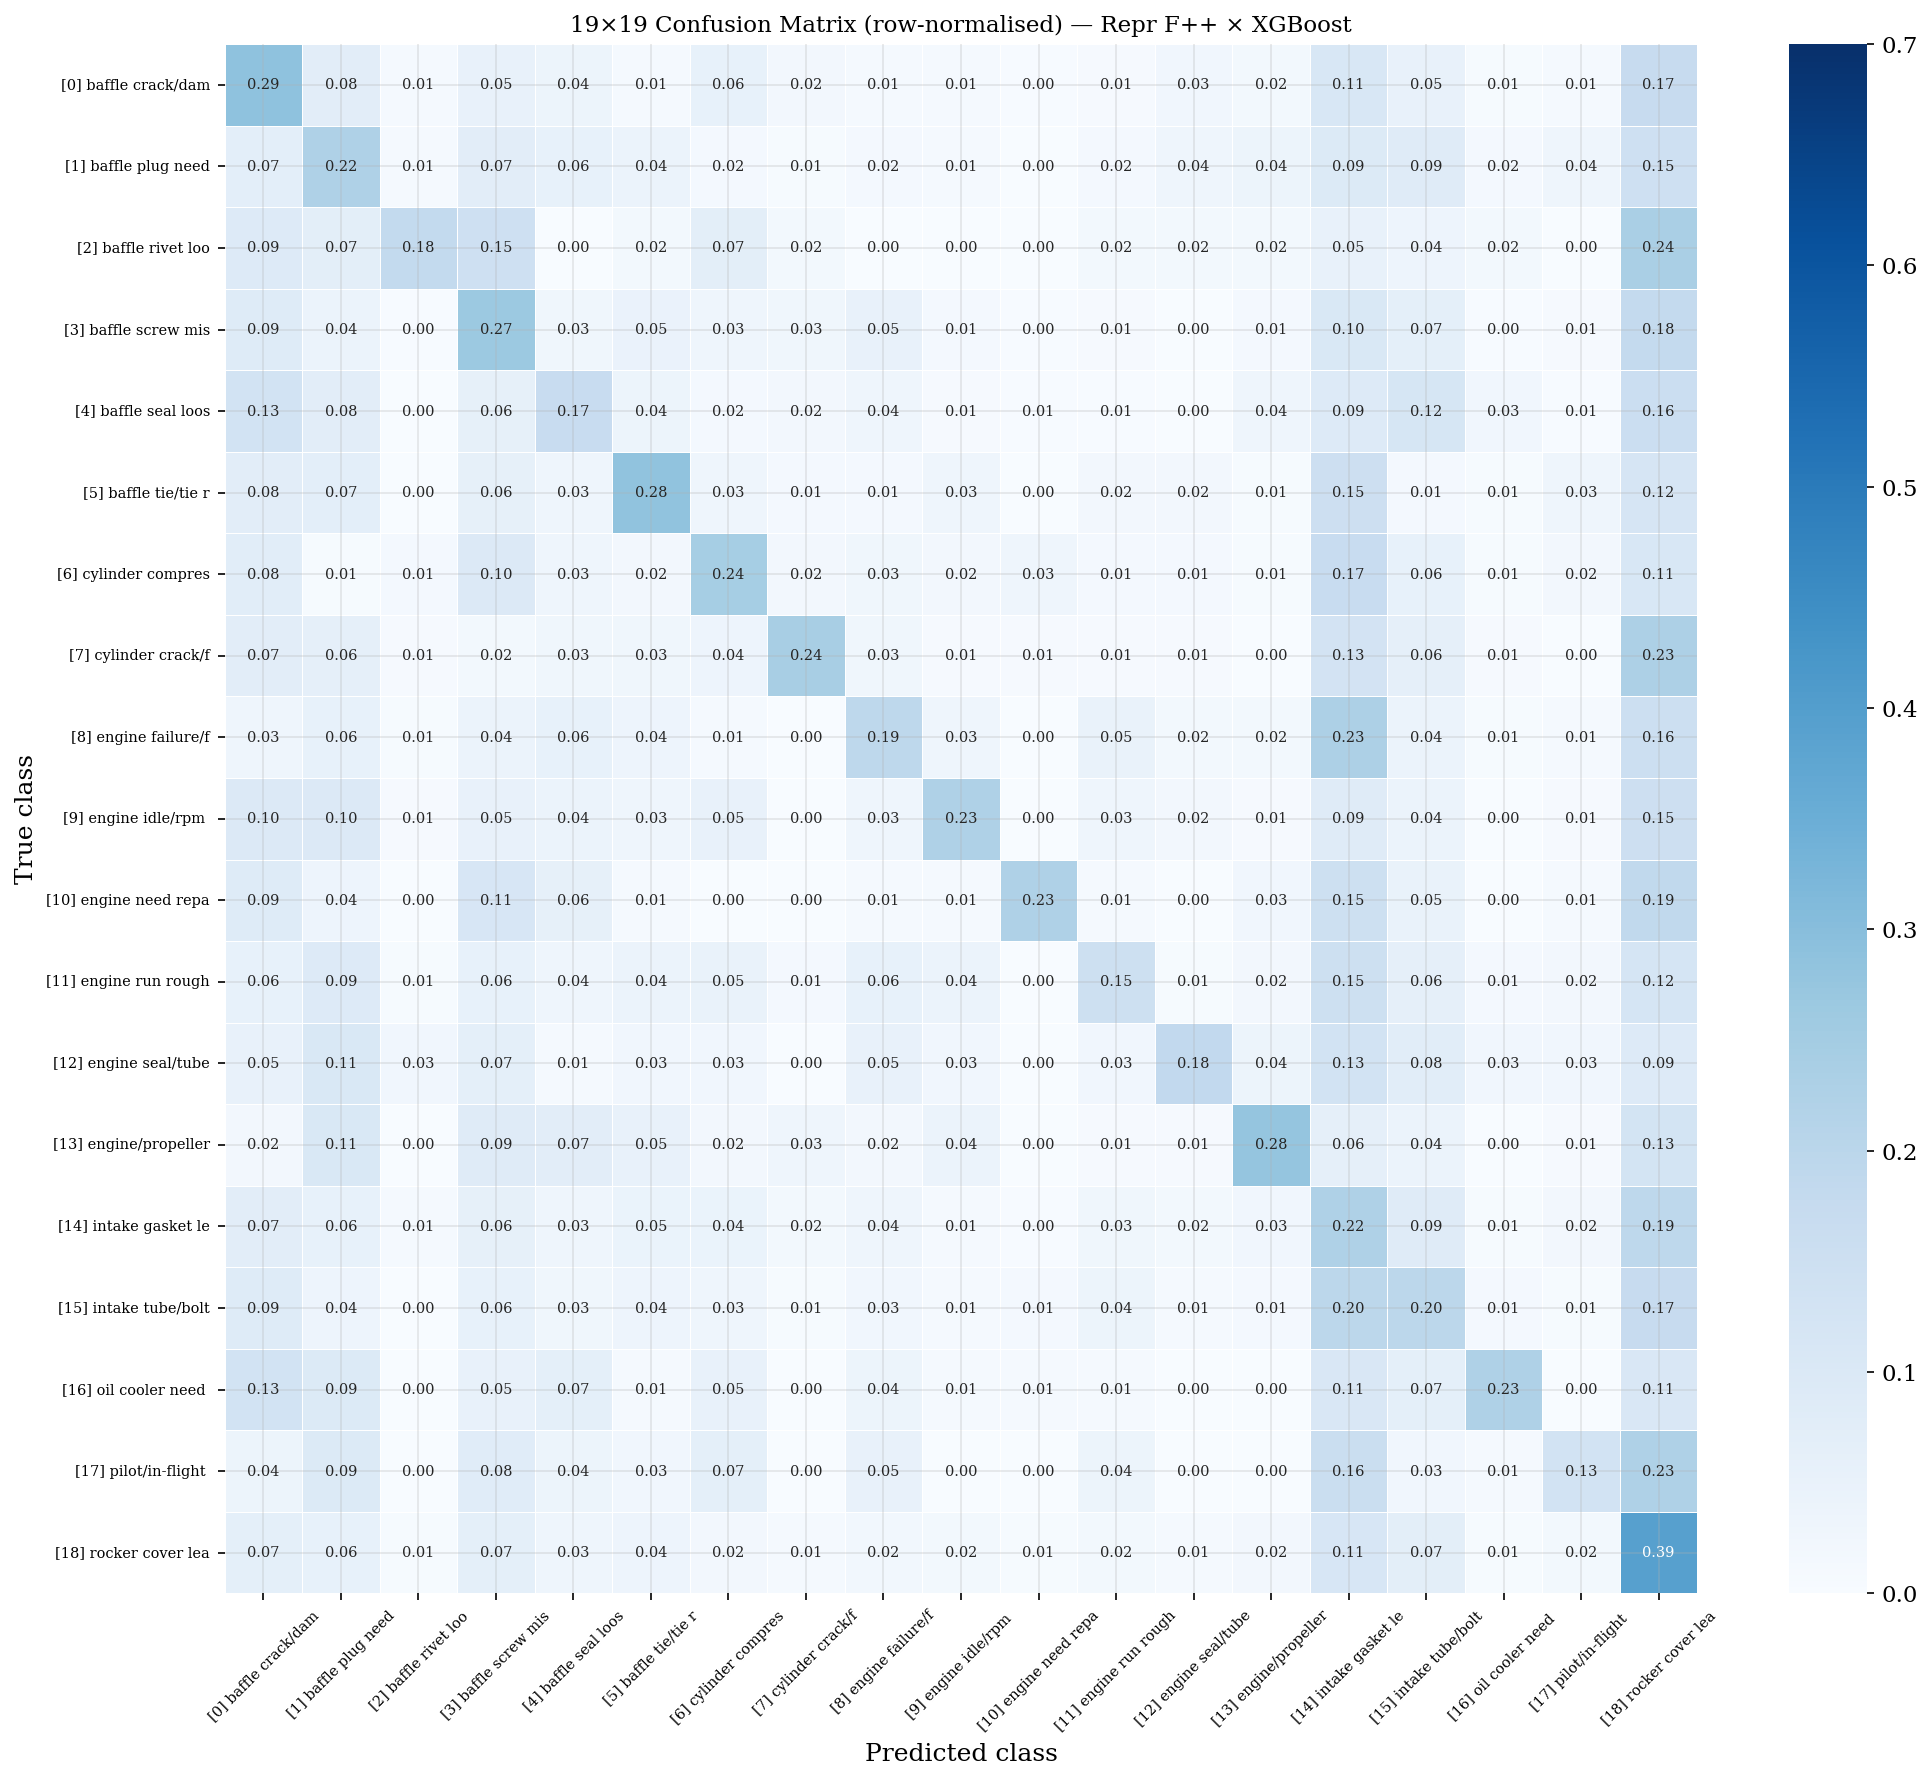

Top-10 misclassification pairs (true → predicted, count):
  [14] intake gasket leak/dam → [18] rocker cover leak/loos  n=402
  [14] intake gasket leak/dam → [15] intake tube/bolt/seal/  n=183
  [14] intake gasket leak/dam → [ 0] baffle crack/damage/lo  n=157
  [14] intake gasket leak/dam → [ 3] baffle screw miss/loos  n=130
  [14] intake gasket leak/dam → [ 1] baffle plug need repai  n=119
  [18] rocker cover leak/loos → [14] intake gasket leak/dam  n=117
  [14] intake gasket leak/dam → [ 5] baffle tie/tie rod loo  n=96
  [14] intake gasket leak/dam → [ 6] cylinder compression i  n=94
  [18] rocker cover leak/loos → [15] intake tube/bolt/seal/  n=74
  [14] intake gasket leak/dam → [ 8] engine failure/fire/ti  n=74


In [12]:
# ── 19×19 Confusion Matrix ────────────────────────────────────────────────────
cm_norm = confusion_matrix(all_yte, all_ypred,
                            labels=list(range(N_CLASSES)), normalize='true')

fig, ax = plt.subplots(figsize=(14, 12))
short_labels = [f'[{i}] {SHORT[i][:16]}' for i in range(N_CLASSES)]
g = sns.heatmap(cm_norm, ax=ax, annot=True, fmt='.2f',
                cmap='Blues', linewidths=0.3, linecolor='white',
                xticklabels=short_labels, yticklabels=short_labels,
                annot_kws={'size': 7}, vmin=0, vmax=0.7)
ax.set_xlabel('Predicted class')
ax.set_ylabel('True class')
ax.set_title(f'19×19 Confusion Matrix (row-normalised) — {best_key}', fontsize=11)
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', rotation=0,  labelsize=7)
plt.tight_layout()
plt.savefig(FIGS / 'fc-confusion-matrix.png', bbox_inches='tight', dpi=300)
plt.show()

# Top confusions: pairs (true, predicted) with highest off-diagonal confusion
cm_raw = confusion_matrix(all_yte, all_ypred, labels=list(range(N_CLASSES)))
np.fill_diagonal(cm_raw, 0)
flat_idx = np.argsort(cm_raw.ravel())[::-1][:10]
print('Top-10 misclassification pairs (true → predicted, count):')
for idx in flat_idx:
    tr_c, pr_c = divmod(idx, N_CLASSES)
    cnt = cm_raw[tr_c, pr_c]
    if cnt > 0:
        print(f'  [{tr_c:2d}] {SHORT[tr_c]:22s} → [{pr_c:2d}] {SHORT[pr_c]:22s}  n={cnt}')

---
## 6 · Oracle K=4 — Hierarchical Ceiling Analysis

The paper proposes grouping the 19 classes into **4 super-groups** and using a two-stage hierarchical classifier:
- **L1**: predicts the super-group (4 classes)
- **L2**: within the super-group, predicts the specific class (2–6 classes)

The **Oracle K=4** measures the theoretical ceiling: what F1 would L2 achieve if L1 were perfect?
This gap between Oracle and Cascade measures how much error comes from L1 vs L2.

```
Group 0 — Baffle faults      : classes 0,1,2,3,4,5  (n=2,286)
Group 1 — Cylinder faults    : classes 6,7           (n=468)
Group 2 — Engine faults      : classes 8,9,10,11,12,13 (n=1,217)
Group 3 — Intake/Cover/Oil   : classes 14,15,16,17,18  (n=7,335)
```

In [14]:
# ── Oracle K=4 implementation ────────────────────────────────────────────────
# Fix: XGBoost requires labels in [0, n-1]. Groups like {6,7} must be
# remapped with LabelEncoder before fit and inverse_transformed on predict.
from sklearn.preprocessing import LabelEncoder

GROUPS = {
    0: [0,1,2,3,4,5],
    1: [6,7],
    2: [8,9,10,11,12,13],
    3: [14,15,16,17,18],
}
LABEL_TO_GROUP = {lbl: grp for grp, lbls in GROUPS.items() for lbl in lbls}

print('Group composition:')
for grp, lbls in GROUPS.items():
    n = int(np.isin(y_w, lbls).sum())
    print(f'  Group {grp}: classes {lbls}  n={n}')

def run_oracle_cascade(X, y, folds_arr, n_folds=5):
    """
    Oracle: L1 always correct (uses true group label).
    L2: XGB per group. Labels remapped to [0,n-1] per group to satisfy XGBoost.
    """
    grp_labels = np.array([LABEL_TO_GROUP[lbl] for lbl in y])
    f1_oracle, f1_cascade, f1_l1 = [], [], []

    for fold_id in range(n_folds):
        tr_m = folds_arr != fold_id
        te_m = folds_arr == fold_id
        y_tr, y_te = y[tr_m], y[te_m]
        g_tr, g_te = grp_labels[tr_m], grp_labels[te_m]

        sc = StandardScaler()
        X_tr = np.nan_to_num(sc.fit_transform(X[tr_m]), nan=0.0)
        X_te = np.nan_to_num(sc.transform(X[te_m]),     nan=0.0)

        # ── L1: group classifier (4 classes 0-3, no remapping needed) ────────
        l1 = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                            eval_metric='mlogloss', verbosity=0,
                            random_state=RNG, n_jobs=-1)
        sw_l1 = compute_sample_weight('balanced', g_tr)
        l1.fit(X_tr, g_tr, sample_weight=sw_l1)
        g_pred = l1.predict(X_te)
        f1_l1.append(f1_score(g_te, g_pred, average='macro', zero_division=0))

        # ── L2: one XGB per group, labels remapped to [0, len(lbls)-1] ───────
        l2_models = {}
        for grp, lbls in GROUPS.items():
            mask_tr = np.isin(y_tr, lbls)
            if mask_tr.sum() < 5:
                continue
            Xg, yg_raw = X_tr[mask_tr], y_tr[mask_tr]
            le = LabelEncoder()
            yg = le.fit_transform(yg_raw)      # e.g. [6,7] → [0,1]
            swg = compute_sample_weight('balanced', yg)
            m = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                               eval_metric='mlogloss', verbosity=0,
                               random_state=RNG, n_jobs=-1)
            m.fit(Xg, yg, sample_weight=swg)
            l2_models[grp] = (m, le)           # store (model, encoder)

        # ── Oracle prediction (uses TRUE group label) ─────────────────────────
        y_oracle = np.full(len(y_te), -1, dtype=int)
        for grp, (mdl, le) in l2_models.items():
            mask = g_te == grp
            if mask.sum() > 0:
                pred_local = mdl.predict(X_te[mask])
                y_oracle[mask] = le.inverse_transform(pred_local)

        # ── Cascade prediction (uses PREDICTED group label) ───────────────────
        y_casc = np.full(len(y_te), -1, dtype=int)
        for grp, (mdl, le) in l2_models.items():
            mask = g_pred == grp
            if mask.sum() > 0:
                pred_local = mdl.predict(X_te[mask])
                y_casc[mask] = le.inverse_transform(pred_local)

        valid_o = y_oracle != -1
        valid_c = y_casc   != -1
        f1_oracle.append(
            f1_score(y_te[valid_o], y_oracle[valid_o],
                     labels=list(range(N_CLASSES)), average='macro', zero_division=0))
        f1_cascade.append(
            f1_score(y_te[valid_c], y_casc[valid_c],
                     labels=list(range(N_CLASSES)), average='macro', zero_division=0))

    return (np.mean(f1_oracle), np.std(f1_oracle),
            np.mean(f1_cascade), np.std(f1_cascade),
            np.mean(f1_l1),      np.std(f1_l1))


print('\nRunning Oracle K=4 analysis on best repr...')
t0 = time.time()
f1_orac, std_orac, f1_casc, std_casc, f1_l1, std_l1 = run_oracle_cascade(
    X_w, y_w, folds_w)
print(f'Done in {time.time()-t0:.0f}s')
print(f'L1 (group classifier) F1  : {f1_l1:.3f} \u00b1 {std_l1:.3f}')
print(f'Oracle K=4 (perfect L1)   : {f1_orac:.3f} \u00b1 {std_orac:.3f}')
print(f'Cascade K=4 (real L1)     : {f1_casc:.3f} \u00b1 {std_casc:.3f}')
print(f'Gap Oracle\u2013Cascade        : {f1_orac - f1_casc:.3f} F1 points (L1 error cost)')

Group composition:
  Group 0: classes [0, 1, 2, 3, 4, 5]  n=1165
  Group 1: classes [6, 7]  n=251
  Group 2: classes [8, 9, 10, 11, 12, 13]  n=645
  Group 3: classes [14, 15, 16, 17, 18]  n=3541

Running Oracle K=4 analysis on best repr...
Done in 43s
L1 (group classifier) F1  : 0.376 ± 0.030
Oracle K=4 (perfect L1)   : 0.459 ± 0.027
Cascade K=4 (real L1)     : 0.172 ± 0.023
Gap Oracle–Cascade        : 0.287 F1 points (L1 error cost)


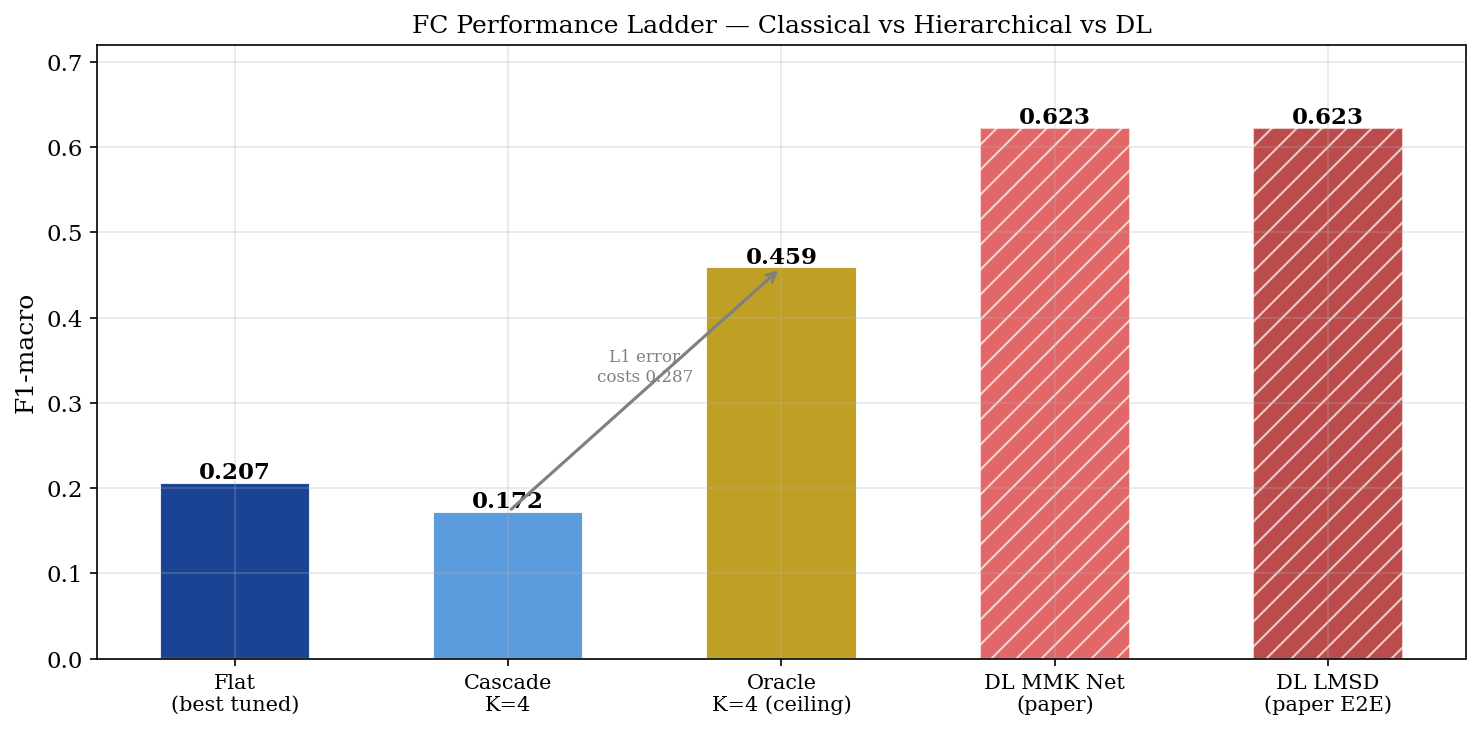

In [15]:
# ── Oracle K=4 comparison figure ─────────────────────────────────────────────
best_flat_f1 = best_data['means']['f1_macro']

methods = ['Flat\n(best tuned)', 'Cascade\nK=4', 'Oracle\nK=4 (ceiling)',
           'DL MMK Net\n(paper)', 'DL LMSD\n(paper E2E)']
f1_vals = [best_flat_f1, f1_casc, f1_orac, 0.623, 0.623]
colors  = [NPS_BLUE, '#4a90d9', NPS_GOLD, '#d62728', '#a00000']
hatches = ['', '', '', '//', '//']
alphas  = [0.9,  0.9,  0.9,  0.7,  0.7]

fig, ax = plt.subplots(figsize=(10, 5))
for i, (m, v, c, h, a) in enumerate(zip(methods, f1_vals, colors, hatches, alphas)):
    bar = ax.bar(i, v, 0.55, color=c, alpha=a, hatch=h, edgecolor='white')
    ax.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=11, fontweight='bold')

ax.set_xticks(range(len(methods)))
ax.set_xticklabels(methods, fontsize=10)
ax.set_ylabel('F1-macro')
ax.set_ylim(0, 0.72)
ax.set_title('FC Performance Ladder — Classical vs Hierarchical vs DL')

# Annotation arrows
ax.annotate('', xy=(2, f1_orac), xytext=(1, f1_casc),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
ax.text(1.5, (f1_orac+f1_casc)/2 + 0.01,
        f'L1 error\ncosts {f1_orac-f1_casc:.3f}',
        ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig(FIGS / 'fc-oracle-ladder.png', bbox_inches='tight', dpi=300)
plt.show()

---
## 7 · Interpretability — Which features identify which faults?

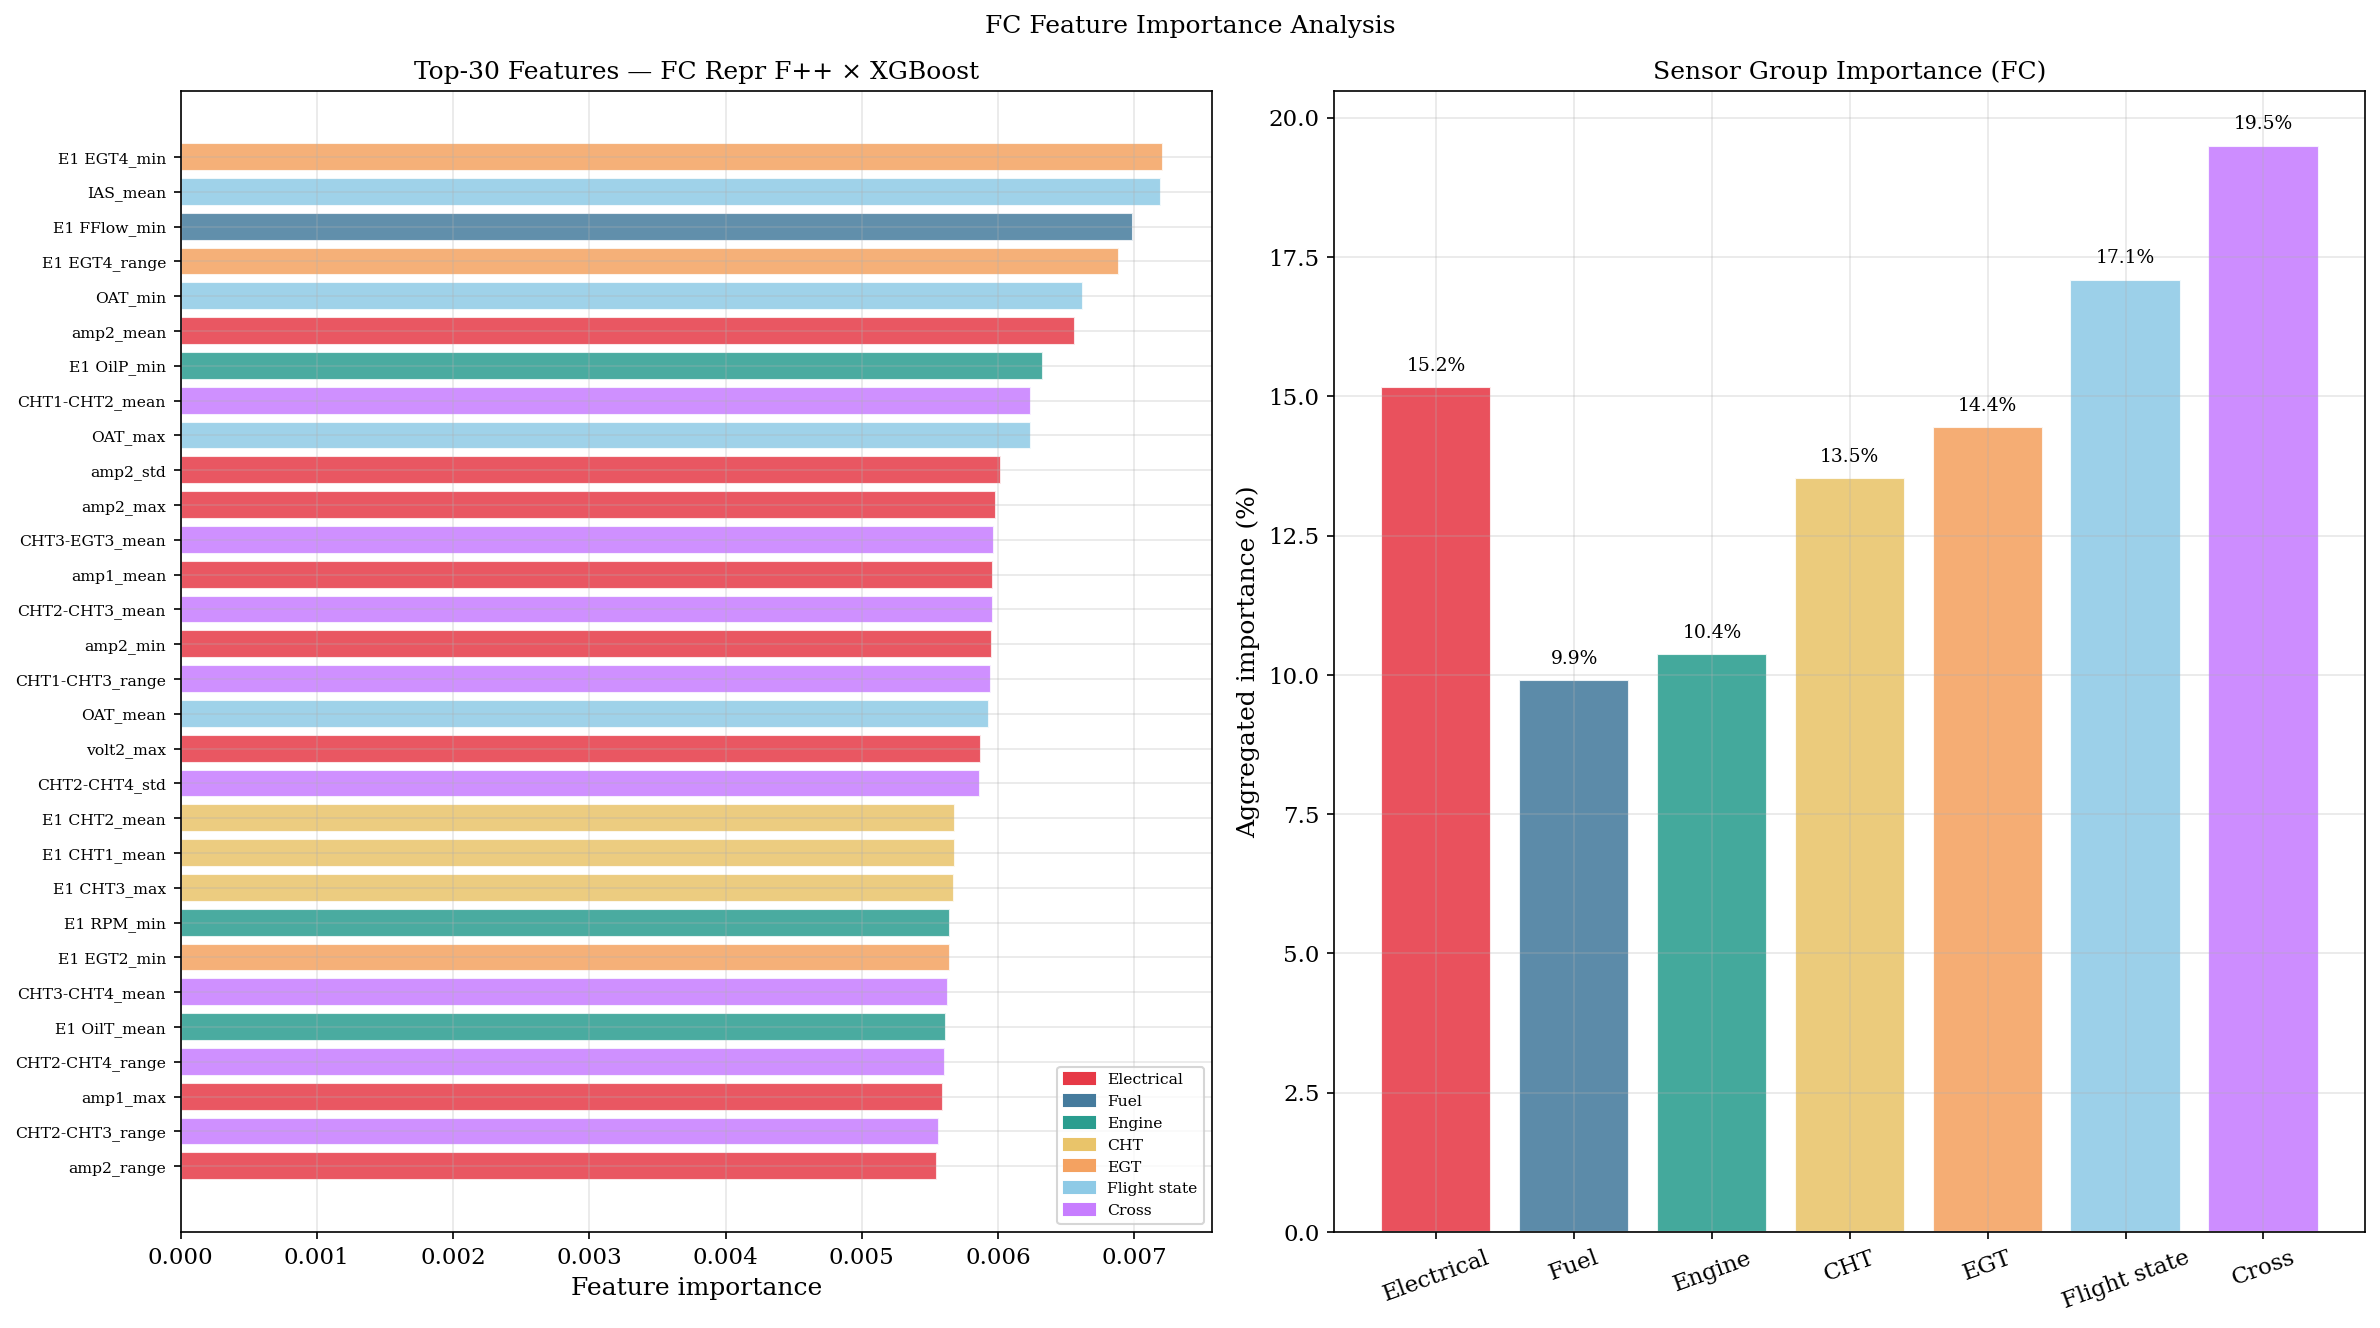

Sensor group breakdown (FC):
  Cross           19.5%  █████████
  Flight state    17.1%  ████████
  Electrical      15.2%  ███████
  EGT             14.4%  ███████
  CHT             13.5%  ██████
  Engine          10.4%  █████
  Fuel             9.9%  ████


In [16]:
# ── Feature importance for FC (global + per-group) ───────────────────────────
sc_imp = StandardScaler()
X_imp  = np.nan_to_num(sc_imp.fit_transform(X_w), nan=0.0)
sw_imp = compute_sample_weight('balanced', y_w)

model_imp = best_data['best_estimator']
if isinstance(model_imp, XGBClassifier):
    model_imp.fit(X_imp, y_w, sample_weight=sw_imp)
else:
    model_imp.fit(X_imp, y_w)

# Get importances
def get_importances(model):
    if isinstance(model, XGBClassifier):        return model.feature_importances_
    if isinstance(model, RandomForestClassifier): return model.feature_importances_
    if isinstance(model, VotingClassifier):
        parts = [e.feature_importances_ for _, e in model.named_estimators_.items()
                 if hasattr(e, 'feature_importances_')]
        return np.mean(parts, axis=0) if parts else None
    if isinstance(model, LogisticRegression):
        return np.abs(model.coef_).mean(axis=0)
    return None

n_feat = X_w.shape[1]
if n_feat == 184:
    feat_names = FEAT_B
elif n_feat == 224:
    cross_names = (
        [f'CHT{a+1}-CHT{b+1}_{st}'
         for a,b in combinations(range(4),2)
         for st in ['mean','std','range','slope']] +
        [f'CHT{i+1}-EGT{i+1}_{st}'
         for i in range(4)
         for st in ['mean','std','range','slope']]
    )
    feat_names = FEAT_B + cross_names
else:
    feat_names = [f'f{i}' for i in range(n_feat)]

importances = get_importances(model_imp)
if importances is None or len(importances) != len(feat_names):
    print('Importances not available for this model.')
else:
    TOP_N = 30
    top_idx  = np.argsort(importances)[::-1][:TOP_N]
    top_names = [feat_names[i] for i in top_idx]
    top_vals  = importances[top_idx]

    group_color = {
        'Electrical':'#e63946','Fuel':'#457b9d','Engine':'#2a9d8f',
        'CHT':'#e9c46a','EGT':'#f4a261','Flight state':'#8ecae6','Cross':'#c77dff'
    }
    sensor_to_group = {s: g for g, ss in SENSOR_GROUPS.items() for s in ss}

    def feat_color(name):
        for sensor, grp in sensor_to_group.items():
            if sensor in name: return group_color[grp]
        return group_color.get('Cross','#adb5bd')

    fig, axes = plt.subplots(1, 2, figsize=(16, 9))

    # Top-N global importance
    ax = axes[0]
    clrs = [feat_color(n) for n in top_names]
    ax.barh(range(TOP_N), top_vals[::-1], color=list(reversed(clrs)), alpha=0.85, edgecolor='white')
    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels(top_names[::-1], fontsize=7.5)
    ax.set_xlabel('Feature importance')
    ax.set_title(f'Top-{TOP_N} Features — FC {best_key}')
    patches = [mpatches.Patch(color=c, label=g) for g, c in group_color.items()]
    ax.legend(handles=patches, fontsize=7.5, loc='lower right')

    # Sensor group aggregation
    ax2 = axes[1]
    group_imp = {g: 0.0 for g in list(SENSOR_GROUPS.keys()) + ['Cross']}
    for name, imp in zip(feat_names, importances):
        assigned = False
        for sensor, grp in sensor_to_group.items():
            if sensor in name:
                group_imp[grp] += imp
                assigned = True
                break
        if not assigned:
            group_imp['Cross'] += imp

    total = sum(group_imp.values())
    gnames = list(group_imp.keys())
    gvals  = [group_imp[g]/total*100 for g in gnames]
    clrs2  = [group_color.get(g,'#adb5bd') for g in gnames]
    bars2  = ax2.bar(gnames, gvals, color=clrs2, alpha=0.88, edgecolor='white')
    for b, v in zip(bars2, gvals):
        ax2.text(b.get_x()+b.get_width()/2, v+0.3, f'{v:.1f}%', ha='center', fontsize=9)
    ax2.set_ylabel('Aggregated importance (%)')
    ax2.set_title('Sensor Group Importance (FC)')
    ax2.tick_params(axis='x', rotation=20)

    plt.suptitle('FC Feature Importance Analysis', fontsize=12)
    plt.tight_layout()
    plt.savefig(FIGS / 'fc-feature-importance.png', bbox_inches='tight', dpi=300)
    plt.show()

    print('Sensor group breakdown (FC):')
    for g, pct in sorted(zip(gnames, gvals), key=lambda x: -x[1]):
        print(f'  {g:14s} {pct:5.1f}%  {"█"*int(pct/2)}')

---
## 8 · Final Table and Decision

In [17]:
# ── Final results table ───────────────────────────────────────────────────────
rows = []
for r, m, f1, std, acc in pairs:
    rows.append({'Model':m, 'Repr':r, 'F1-macro':round(f1,3),
                 '±std':round(std,3), 'Accuracy':round(acc,3),
                 'Type':'classical default'})

for key, data in tuned_results.items():
    rows.append({'Model':data['model'], 'Repr':data['repr'],
                 'F1-macro':round(data['means']['f1_macro'],3),
                 '±std':round(data['stds']['f1_macro'],3),
                 'Accuracy':round(data['means']['acc'],3),
                 'Type':'classical tuned'})

rows += [
    {'Model':'XGB K=4 Cascade', 'Repr':best_data['repr'],
     'F1-macro':round(f1_casc,3), '±std':round(std_casc,3),
     'Accuracy':'—', 'Type':'hierarchical'},
    {'Model':'Oracle K=4 ceiling', 'Repr':best_data['repr'],
     'F1-macro':round(f1_orac,3), '±std':round(std_orac,3),
     'Accuracy':'—', 'Type':'oracle (upper bound)'},
    {'Model':'MMK Net (DL)',    'Repr':'Repr A', 'F1-macro':0.623,
     '±std':'—', 'Accuracy':'—', 'Type':'DL paper'},
    {'Model':'ConvTokMHSA (DL)','Repr':'Repr A', 'F1-macro':0.208,
     '±std':'—', 'Accuracy':'—', 'Type':'DL paper'},
]

df_final = pd.DataFrame(rows)
df_final = df_final.sort_values('F1-macro', ascending=False).reset_index(drop=True)
print(df_final.to_string(index=False))
df_final.to_csv(RESULTS / 'fc_results.csv', index=False)

# Decision summary
best_cl = df_final[~df_final['Type'].str.contains('DL|oracle|hierarchical')].iloc[0]
print('\n' + '='*68)
print('DECISION: BEST CLASSICAL FC MODEL')
print('='*68)
print(f'  Model       : {best_cl["Model"]}')
print(f'  Repr        : {best_cl["Repr"]}')
print(f'  F1-macro    : {best_cl["F1-macro"]:.3f}')
print(f'  Gap vs DL   : {0.623 - float(best_cl["F1-macro"]):.3f} F1 points vs MMK Net')
print(f'  Gap vs Oracle: {f1_orac - float(best_cl["F1-macro"]):.3f} F1 points vs K=4 Oracle ceiling')
print('='*68)
print('→ This model passes to the E2E cascade pipeline (05_E2E_Models.ipynb)')

             Model        Repr  F1-macro   ±std Accuracy                 Type
      MMK Net (DL)      Repr A     0.623      —        —             DL paper
Oracle K=4 ceiling    Repr F++     0.459  0.027        — oracle (upper bound)
  ConvTokMHSA (DL)      Repr A     0.208      —        —             DL paper
           XGBoost    Repr F++     0.207  0.024    0.255      classical tuned
           XGBoost      Repr B     0.176  0.016    0.224      classical tuned
   XGB K=4 Cascade    Repr F++     0.172  0.023        —         hierarchical
           XGBoost    Repr F++     0.169  0.026    0.392    classical default
           XGBoost      Repr B     0.116  0.007    0.372    classical default
                LR    Repr F++     0.098  0.007    0.098    classical default
                LR    Repr F++     0.095  0.005    0.096      classical tuned
                LR  Repr Bseg5     0.088   0.01    0.133    classical default
           XGBoost  Repr Bseg3     0.087  0.009    0.357    clas